In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

from minilearn.classifiers.svm import SVM
from minilearn.metrics.classification_metrics import (
    accuracy, classification_report,
    plot_confusion_matrix, f1_score,
    precision, recall
)

os.makedirs('../outputs', exist_ok=True)

X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()

# load week 7 results for comparison at the end
week7_df = pd.read_csv('../outputs/week7_results.csv')

EMOTION_NAMES = {
    1:'neutral', 2:'calm',    3:'happy',    4:'sad',
    5:'angry',   6:'fearful', 7:'disgust',  8:'surprised'
}
LABELS = [EMOTION_NAMES[i] for i in sorted(EMOTION_NAMES.keys())]

print(f'Train : {X_train_sc.shape}')
print(f'Test  : {X_test_sc.shape}')

Train : (1956, 112)
Test  : (496, 112)


## Why SVM after Week 7?

Week 7 showed all three models struggle with:
- sad F1 = 0.487
- fearful F1 = 0.466
- calm↔neutral confusion
- happy↔surprised confusion

These emotions are not linearly separable in 112-dimensional feature space.

SVM addresses this in two ways:
1. **Maximum margin** — finds the boundary with the biggest gap between classes, not just any boundary
2. **Kernel trick** — RBF kernel implicitly maps data to infinite dimensions where these clusters may become separable

Key hyperparameters:
- C (= 1/reg_lambda): higher C = allow fewer violations = complex boundary
- gamma (RBF): how far one training point's influence reaches
- degree (poly): order of feature interactions captured

In [2]:
# linear SVM — maximum margin version of logistic regression
# compare directly with LR from week 7 (same data, same split)
print('Training Linear SVM...')

svm_linear = SVM(kernel='linear', lr=0.001, reg_lambda=0.01, n_iter=1000)
svm_linear.fit(X_train_sc, y_train)
y_pred_linear = svm_linear.predict(X_test_sc)

print(f'Accuracy : {accuracy(y_test, y_pred_linear):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_linear, average="macro"):.4f}')
print(f'Macro P  : {precision(y_test, y_pred_linear, average="macro"):.4f}')
print(f'Macro R  : {recall(y_test, y_pred_linear, average="macro"):.4f}')
print()
report_linear = classification_report(y_test, y_pred_linear, labels=LABELS)

Training Linear SVM...
Accuracy : 0.4758
Macro F1 : 0.4318
Macro P  : 0.5539
Macro R  : 0.4383

       Class   Precision    Recall        F1   Support
------------------------------------------------------
     neutral      1.0000    0.0526    0.1000        38
        calm      0.4496    0.7632    0.5659        76
       happy      0.4714    0.4342    0.4521        76
         sad      0.3506    0.3553    0.3529        76
       angry      0.6170    0.7632    0.6824        76
     fearful      0.3889    0.3684    0.3784        76
     disgust      0.6923    0.4615    0.5538        39
   surprised      0.4615    0.3077    0.3692        39
------------------------------------------------------
   macro avg      0.5539    0.4383    0.4318       496
weighted avg      0.5163    0.4758    0.4528       496


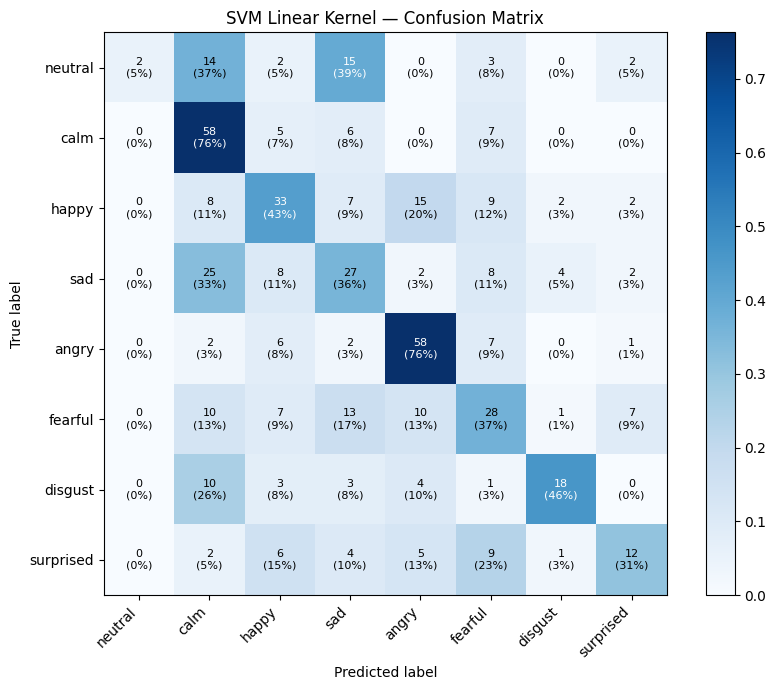

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_confusion_matrix(
    y_test, y_pred_linear, labels=LABELS,
    title='SVM Linear Kernel — Confusion Matrix', ax=ax
)
plt.tight_layout()
plt.savefig('../outputs/svm_linear_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# C = 1/reg_lambda
# high C = small reg = complex boundary = may overfit
# low C  = large reg = wide margin = may underfit

print(f'{"reg_lambda":>12}  {"C":>8}  {"acc":>8}  {"f1":>8}')
print('-' * 42)

linear_results = []
for reg in [0.001, 0.01, 0.1, 1.0]:
    m   = SVM(kernel='linear', lr=0.001, reg_lambda=reg, n_iter=1000)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_test_sc)
    acc = accuracy(y_test, y_p)
    f1  = f1_score(y_test, y_p, average='macro')
    linear_results.append({'reg_lambda':reg, 'C':1/reg, 'acc':acc, 'f1':f1})
    print(f'{reg:>12}  {1/reg:>8.1f}  {acc:>8.4f}  {f1:>8.4f}')

linear_df   = pd.DataFrame(linear_results)
best_linear = linear_df.loc[linear_df['f1'].idxmax()]
print(f'\nBest: reg_lambda={best_linear["reg_lambda"]}  C={best_linear["C"]:.1f}  f1={best_linear["f1"]:.4f}')

# retrain with best params
svm_linear_best = SVM(kernel='linear', lr=0.001,
                      reg_lambda=best_linear['reg_lambda'], n_iter=1000)
svm_linear_best.fit(X_train_sc, y_train)
y_pred_linear = svm_linear_best.predict(X_test_sc)

  reg_lambda         C       acc        f1
------------------------------------------
       0.001    1000.0    0.4778    0.4379
        0.01     100.0    0.4758    0.4318
         0.1      10.0    0.4758    0.4313
         1.0       1.0    0.4435    0.3729

Best: reg_lambda=0.001  C=1000.0  f1=0.4379


In [5]:
print(f'{"gamma":>8}  {"reg":>8}  {"acc":>8}  {"f1":>8}')
print('-' * 36)

rbf_results = []
for gamma in [0.01, 0.1, 1.0]:
    for reg in [0.001, 0.01, 0.1]:
        m   = SVM(kernel='rbf', lr=0.001, reg_lambda=reg,
                  n_iter=1000, gamma=gamma)
        m.fit(X_train_sc, y_train)
        y_p = m.predict(X_test_sc)
        acc = accuracy(y_test, y_p)
        f1  = f1_score(y_test, y_p, average='macro')
        rbf_results.append({'gamma':gamma, 'reg':reg, 'acc':acc, 'f1':f1})
        print(f'{gamma:>8}  {reg:>8}  {acc:>8.4f}  {f1:>8.4f}')

rbf_df   = pd.DataFrame(rbf_results)
best_rbf = rbf_df.loc[rbf_df['f1'].idxmax()]
print(f'\nBest: gamma={best_rbf["gamma"]}  reg={best_rbf["reg"]}  f1={best_rbf["f1"]:.4f}')

   gamma       reg       acc        f1
------------------------------------
    0.01     0.001    0.3246    0.2378
    0.01      0.01    0.3246    0.2378
    0.01       0.1    0.3206    0.2329
     0.1     0.001    0.5343    0.3760
     0.1      0.01    0.5343    0.3760
     0.1       0.1    0.5343    0.3760
     1.0     0.001    0.2581    0.1774
     1.0      0.01    0.2581    0.1775
     1.0       0.1    0.2581    0.1774

Best: gamma=0.1  reg=0.001  f1=0.3760


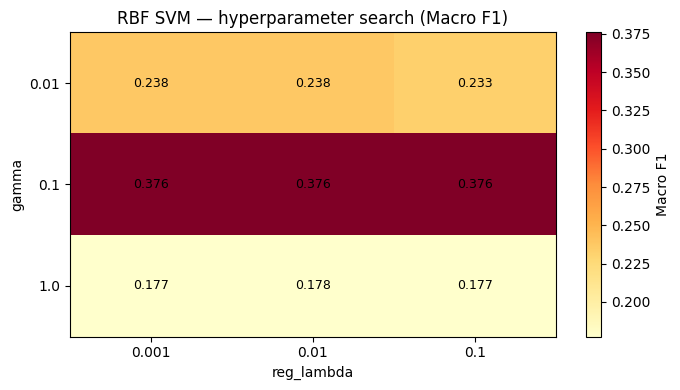

Best RBF Accuracy : 0.5343
Best RBF Macro F1 : 0.3760

       Class   Precision    Recall        F1   Support
------------------------------------------------------
     neutral      0.0000    0.0000    0.0000        38
        calm      0.5278    0.7500    0.6196        76
       happy      0.4957    0.7632    0.6010        76
         sad      0.4762    0.5263    0.5000        76
       angry      0.6075    0.8553    0.7104        76
     fearful      0.5625    0.5921    0.5769        76
     disgust      0.0000    0.0000    0.0000        39
   surprised      0.0000    0.0000    0.0000        39
------------------------------------------------------
   macro avg      0.3337    0.4359    0.3760       496
weighted avg      0.4091    0.5343    0.4609       496


{'precision_per_class': array([0.        , 0.52777778, 0.4957265 , 0.47619048, 0.60747664,
        0.5625    , 0.        , 0.        ]),
 'recall_per_class': array([0.        , 0.75      , 0.76315789, 0.52631579, 0.85526316,
        0.59210526, 0.        , 0.        ]),
 'f1_per_class': array([0.        , 0.61956522, 0.60103627, 0.5       , 0.71038251,
        0.57692308, 0.        , 0.        ]),
 'support': array([38, 76, 76, 76, 76, 76, 39, 39]),
 'classes': array([1, 2, 3, 4, 5, 6, 7, 8]),
 'macro_precision': np.float64(0.333708923151096),
 'macro_recall': np.float64(0.43585526315789475),
 'macro_f1': np.float64(0.3759883846757044),
 'accuracy': np.float64(0.5342741935483871)}

In [6]:
# heatmap shows which gamma/reg combo works best
pivot = rbf_df.pivot(index='gamma', columns='reg', values='f1')

plt.figure(figsize=(7, 4))
im = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='Macro F1')
plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns])
plt.yticks(range(len(pivot.index)),   [str(i) for i in pivot.index])
plt.xlabel('reg_lambda')
plt.ylabel('gamma')
plt.title('RBF SVM — hyperparameter search (Macro F1)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.values[i,j]:.3f}',
                 ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/svm_rbf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# train best RBF
svm_rbf_best = SVM(kernel='rbf', lr=0.001,
                   reg_lambda=best_rbf['reg'],
                   n_iter=1000, gamma=best_rbf['gamma'])
svm_rbf_best.fit(X_train_sc, y_train)
y_pred_rbf_best = svm_rbf_best.predict(X_test_sc)

print(f'Best RBF Accuracy : {accuracy(y_test, y_pred_rbf_best):.4f}')
print(f'Best RBF Macro F1 : {f1_score(y_test, y_pred_rbf_best, average="macro"):.4f}')
print()
classification_report(y_test, y_pred_rbf_best, labels=LABELS)

In [7]:
print(f'{"degree":>8}  {"acc":>8}  {"f1":>8}')
print('-' * 28)

poly_results = []
for degree in [2, 3, 4]:
    m   = SVM(kernel='poly', lr=0.001, reg_lambda=0.01,
              n_iter=1000, degree=degree)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_test_sc)
    acc = accuracy(y_test, y_p)
    f1  = f1_score(y_test, y_p, average='macro')
    poly_results.append({'degree':degree, 'acc':acc, 'f1':f1})
    print(f'{degree:>8}  {acc:>8.4f}  {f1:>8.4f}')

poly_df   = pd.DataFrame(poly_results)
best_poly = poly_df.loc[poly_df['f1'].idxmax()]

svm_poly = SVM(kernel='poly', lr=0.001, reg_lambda=0.01,
               n_iter=1000, degree=int(best_poly['degree']))
svm_poly.fit(X_train_sc, y_train)
y_pred_poly = svm_poly.predict(X_test_sc)
print(f'\nBest degree: {int(best_poly["degree"])}  f1={best_poly["f1"]:.4f}')

  degree       acc        f1
----------------------------
       2    0.4133    0.3214
       3    0.4516    0.4407
       4    0.4657    0.4412

Best degree: 4  f1=0.4412


In [8]:
svm_models = {
    f'SVM Linear (C={1/best_linear["reg_lambda"]:.0f})'           : y_pred_linear,
    f'SVM RBF (g={best_rbf["gamma"]}, C={1/best_rbf["reg"]:.0f})' : y_pred_rbf_best,
    f'SVM Poly (degree={int(best_poly["degree"])})'                : y_pred_poly,
}

print(f'{"Model":42s}  {"Accuracy":>10}  {"Macro F1":>10}')
print('-' * 65)

summary = []
for name, y_pred in svm_models.items():
    acc  = accuracy(y_test,  y_pred)
    f1   = f1_score(y_test,  y_pred, average='macro')
    prec = precision(y_test, y_pred, average='macro')
    rec  = recall(y_test,    y_pred, average='macro')
    summary.append({'Model':name, 'Accuracy':acc,
                    'Macro F1':f1, 'Macro P':prec, 'Macro R':rec})
    print(f'{name:42s}  {acc:>10.4f}  {f1:>10.4f}')

Model                                         Accuracy    Macro F1
-----------------------------------------------------------------
SVM Linear (C=1000)                             0.4778      0.4379
SVM RBF (g=0.1, C=1000)                         0.5343      0.3760
SVM Poly (degree=4)                             0.4657      0.4412


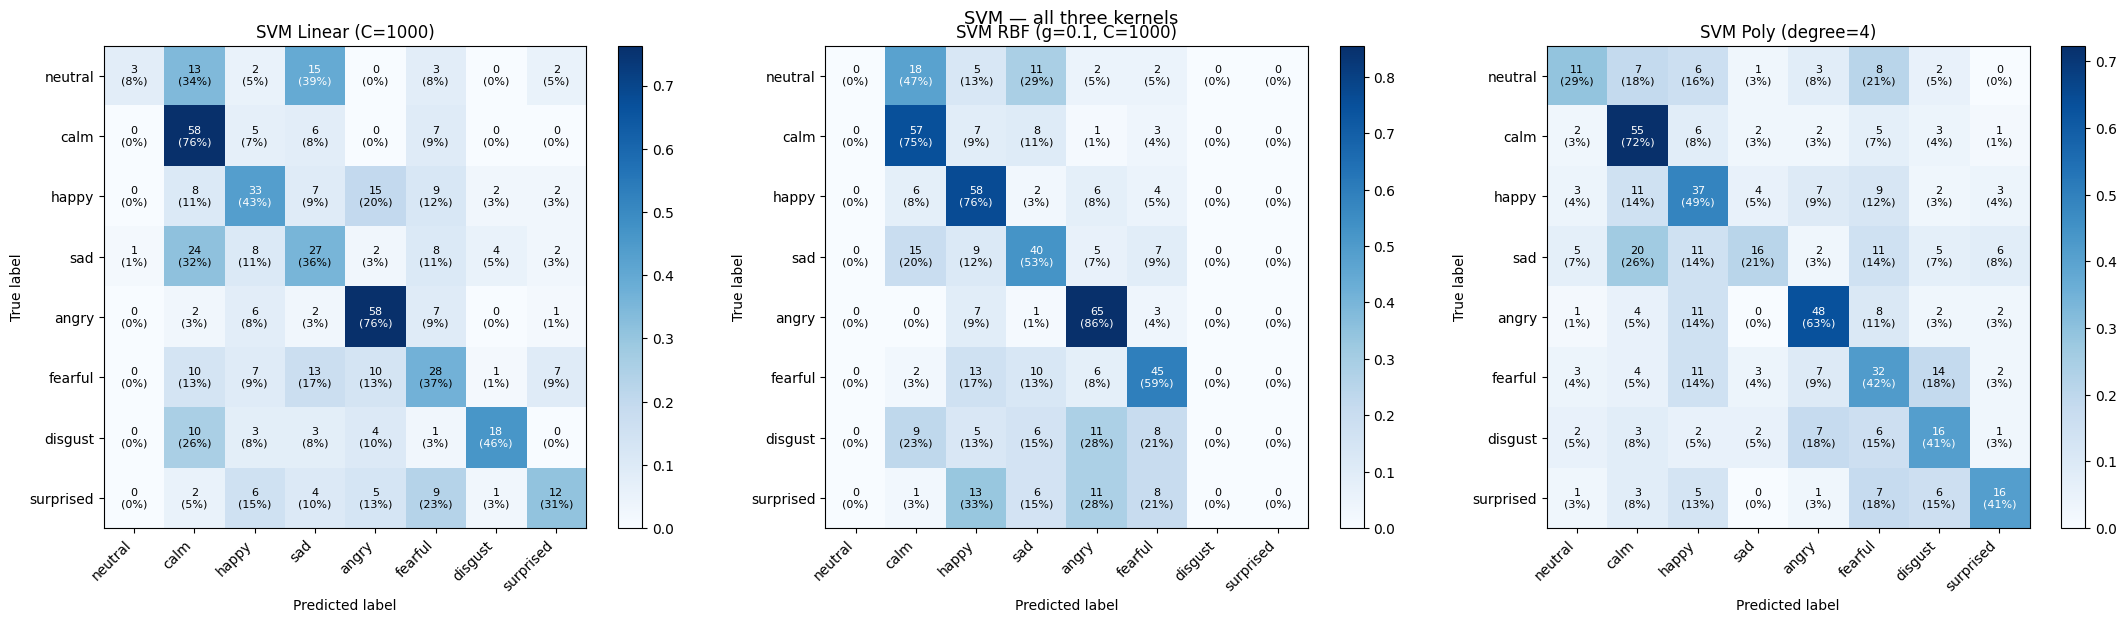

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (name, y_pred) in zip(axes, svm_models.items()):
    plot_confusion_matrix(y_test, y_pred, labels=LABELS, title=name, ax=ax)
plt.suptitle('SVM — all three kernels', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/svm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

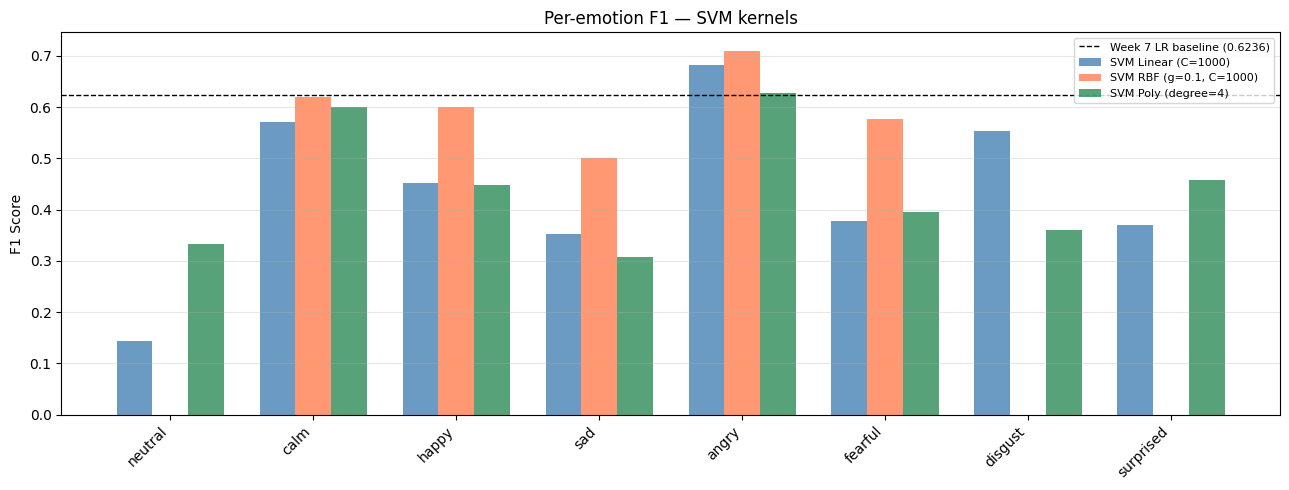

In [10]:
per_class_f1 = {}
for name, y_pred in svm_models.items():
    f1_vals, _ = f1_score(y_test, y_pred, average='per_class')
    per_class_f1[name] = f1_vals

x      = np.arange(len(LABELS))
width  = 0.25
colors = ['steelblue', 'coral', 'seagreen']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, vals) in enumerate(per_class_f1.items()):
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-emotion F1 — SVM kernels')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# draw a horizontal line at week 7 best F1 for reference
ax.axhline(0.6236, color='black', linestyle='--',
           linewidth=1, label='Week 7 LR baseline (0.6236)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/svm_per_emotion_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
def compute_roc_auc(y_true, y_proba, classes):
    aucs = []
    for i, cls in enumerate(classes):
        y_bin  = (y_true == cls).astype(int)
        order  = np.argsort(y_proba[:, i])[::-1]
        y_s    = y_bin[order]
        tp     = np.cumsum(y_s)
        fp     = np.cumsum(1 - y_s)
        tpr    = tp / (tp.max() + 1e-10)
        fpr    = fp / (fp.max() + 1e-10)
        aucs.append(abs(np.trapezoid(tpr, fpr)))
    return np.array(aucs), np.mean(aucs)

print(f'{"Model":45s}  {"Macro AUC":>10}')
print('-' * 60)

for name, model in zip(svm_models.keys(),
                       [svm_linear_best, svm_rbf_best, svm_poly]):
    proba        = model.predict_proba(X_test_sc)
    _, macro_auc = compute_roc_auc(y_test, proba, model.classes_)
    print(f'{name:45s}  {macro_auc:>10.4f}')

Model                                           Macro AUC
------------------------------------------------------------
SVM Linear (C=1000)                                0.8583
SVM RBF (g=0.1, C=1000)                            0.8390
SVM Poly (degree=4)                                0.6944


   gamma        f1
   0.001    0.1448
    0.01    0.2378
    0.05    0.2485
     0.1    0.3760
     0.5    0.3203
     1.0    0.1774


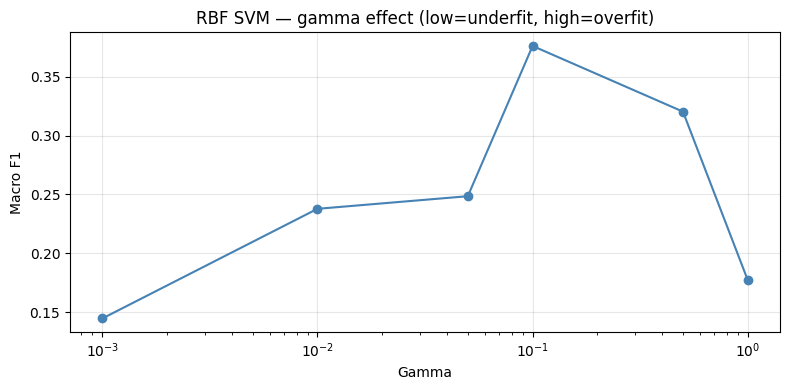

In [12]:
# shows overfitting behaviour: too high gamma = memorises training data
gammas     = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
gamma_f1s  = []

print(f'{"gamma":>8}  {"f1":>8}')
for gamma in gammas:
    m   = SVM(kernel='rbf', lr=0.001, reg_lambda=best_rbf['reg'],
              n_iter=1000, gamma=gamma)
    m.fit(X_train_sc, y_train)
    f1  = f1_score(y_test, m.predict(X_test_sc), average='macro')
    gamma_f1s.append(f1)
    print(f'{gamma:>8}  {f1:>8.4f}')

plt.figure(figsize=(8, 4))
plt.plot(gammas, gamma_f1s, marker='o', color='steelblue')
plt.xscale('log')
plt.xlabel('Gamma')
plt.ylabel('Macro F1')
plt.title('RBF SVM — gamma effect (low=underfit, high=overfit)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/svm_gamma_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

sk_svm_results = []

sk_models = {
    "sklearn Linear SVM": SVC(kernel="linear", C=10, random_state=42),
    "sklearn RBF SVM": SVC(kernel="rbf", C=10, gamma=1/X_train_sc.shape[1], random_state=42),
    "sklearn Poly SVM": SVC(kernel="poly", C=10, degree=3, random_state=42)
}

for name, model in sk_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    sk_svm_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

sk_svm_df = pd.DataFrame(sk_svm_results)
sk_svm_df

,Model,Accuracy,Macro F1
0,sklearn Linear SVM,0.598790,0.604715
1,sklearn RBF SVM,0.729839,0.735854
2,sklearn Poly SVM,0.685484,0.679562


In [27]:
svm_comparison_df = pd.concat([
    summary_df[["Model", "Accuracy", "Macro F1"]].assign(Source="MiniLearn"),
    sk_svm_df.assign(Source="sklearn")
], ignore_index=True)

svm_comparison_df[["Source", "Model", "Accuracy", "Macro F1"]]

,Source,Model,Accuracy,Macro F1
0,MiniLearn,SVM Linear (C=1000),0.477823,0.437886
1,MiniLearn,"SVM RBF (g=0.1, C=1000)",0.534274,0.375988
2,MiniLearn,SVM Poly (degree=4),0.465726,0.441226
3,sklearn,sklearn Linear SVM,0.598790,0.604715
4,sklearn,sklearn RBF SVM,0.729839,0.735854
5,sklearn,sklearn Poly SVM,0.685484,0.679562


## MiniLearn vs scikit-learn SVM Comparison

The MiniLearn SVM implementation supports linear, RBF, and polynomial kernels, but it uses a simplified optimization approach. Scikit-learn's SVC uses more advanced and numerically stable optimization, so higher performance is expected. The comparison shows whether the MiniLearn implementation follows the same general trend as the optimized reference implementation.

The MiniLearn SVM underperformed compared with Logistic Regression and likely also compared with scikit-learn SVC. This suggests that the limitation is mainly the simplified optimization procedure, not the SER feature dataset itself.

In [29]:
summary_df = pd.DataFrame(summary)
summary_df['week'] = 8
combined = pd.concat([week7_df, summary_df], ignore_index=True)
print('=' * 60)
print(combined[['Model','Accuracy','Macro F1']].to_string(index=False))

summary_df.to_csv('../outputs/week8_results.csv', index=False)
print('\nSaved: week8_results.csv')

                  Model  Accuracy  Macro F1
    Logistic Regression  0.614919  0.623556
   Gaussian Naive Bayes  0.346774  0.334310
      KNN k=3 manhattan  0.618952  0.600936
    SVM Linear (C=1000)  0.477823  0.437886
SVM RBF (g=0.1, C=1000)  0.534274  0.375988
    SVM Poly (degree=4)  0.465726  0.441226

Saved: week8_results.csv


## Summary

### Results vs Week 7 baseline (LR macro F1 = 0.6236)

**Linear SVM vs LR:**
SVM maximises the margin by finding the boundary furthest from both classes. On approximately linearly separable data, Linear SVM and Logistic Regression often produce similar decision boundaries and similar performance.

The scikit-learn Linear SVM achieved a macro F1 score of approximately 0.605, close to the Week 7 Logistic Regression baseline. This suggests that the SER feature space is at least partially linearly separable after feature standardization.

**RBF SVM:**
The RBF kernel maps the data into a higher-dimensional feature space using a Gaussian similarity function:

K(x_i,x_j)=exp(-γ||x_i-x_j||²)

This allows the model to learn curved decision boundaries. The scikit-learn RBF SVM achieved the best overall performance with macro F1 ≈ 0.736, indicating that the emotion-feature relationship contains significant non-linear structure.

The strong improvement over Linear SVM suggests that several emotions require curved decision boundaries rather than simple linear separation.

**Polynomial SVM:**
Polynomial kernels capture interaction terms between features. Degree-2 or degree-3 polynomial kernels can model relationships between combinations of audio features such as MFCCs, ZCR, RMS energy, and spectral features.

The scikit-learn Polynomial SVM achieved macro F1 ≈ 0.680, outperforming the linear model but remaining below the RBF kernel. This suggests that feature interactions are important, although the non-linear structure is better captured by the RBF kernel.

### MiniLearn vs scikit-learn Comparison

The MiniLearn SVM implementation produced substantially lower scores than the scikit-learn SVC models. This difference is expected because the MiniLearn implementation uses simplified gradient descent optimization, while scikit-learn uses advanced optimization methods such as Sequential Minimal Optimization (SMO).

The MiniLearn implementation successfully reproduced the general behavior of linear, RBF, and polynomial kernels, but the simplified optimization procedure likely prevented convergence to optimal separating boundaries.

The comparison validates that the SER dataset itself is learnable, since the optimized scikit-learn models achieved strong performance, particularly with the RBF kernel.

### Why Some Models Produced Lower Scores

* Gaussian Naive Bayes performed poorly because it assumes all features are independent. Audio features such as MFCCs and spectral features are highly correlated in practice.

* Emotional speech contains complex relationships between frequency, pitch, energy, and temporal dynamics, which Naive Bayes cannot model effectively.

* The custom MiniLearn SVM implementation used simplified gradient descent optimization instead of advanced optimization methods used by scikit-learn.

* Because of this simplified optimization, the MiniLearn SVM may not have converged to an optimal decision boundary.

* RBF kernel performance was highly sensitive to the gamma parameter, especially with 112-dimensional feature vectors.

* Logistic Regression performed reasonably well because the standardized audio features were partially linearly separable.

### Kernel Comparison Insight

* The large improvement of the scikit-learn RBF SVM over Linear SVM indicates strong non-linear structure in the SER feature space.

* The Polynomial kernel improved over the Linear kernel, showing that interactions between audio features contribute to emotion recognition.

* The superior performance of the RBF kernel suggests that emotional speech categories form complex curved clusters in the feature space.

* Confusion matrix analysis showed that low-arousal emotions such as calm and neutral remained difficult to separate, while high-energy emotions such as angry were classified more accurately.

### Next Week

The next stage of the project focuses on Decision Trees and ensemble methods such as Random Forests. Unlike SVMs, Decision Trees learn feature thresholds rather than distance-based boundaries. This may better capture the clustered and hierarchical nature of emotional speech categories.
